## Load The Preprocessed Data

In [ ]:
import string
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import random



In [ ]:
dataset = pd.read_csv('../Dataset/(Preprocessed)Emotion_classify_Data(Labeled).csv')


In [ ]:
commentList = dataset['Comment'].to_list()
emotionList = dataset['Emotion'].to_list()


In [ ]:
# Load list from file
with open('../Dataset/(PreprocessedII)sentList.json', 'r') as f:
    processed_texts =  json.load(f)
processed_texts

['serious hate one subject death feel reluct drop',
 'im full life feel appal',
 'sit write start dig feel think afraid accept possibl might make',
 'ive realli angri r feel like idiot trust first place',
 'feel suspici one outsid like raptur happen someth',
 'feel jealous becasu want kind love true connect two soul want',
 'friend mine keep tell morbid thing happen dog',
 'final fell asleep feel angri useless still full anxieti',
 'feel bit annoy antsi good way',
 'feel like regain anoth vital part life live',
 'feel bit like franz liebkind produc mani peopl know fuhrer terrif dancer',
 'feel start didnt want move much realli glad experi glimps sort vibrant energi gain year',
 'bitten dog',
 'alway find feel thank year gather trick allow feel grate face moment last thing want say thank',
 'tri talk anyon feel irrit like',
 'feel like hate sinc',
 'dont know wrote follow littl note feel today u r offend follow post obvious live long enough compromis act believ',
 'feel offend choos tel

## Logistic Regression Part

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score


In [ ]:
# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Transform the text data into feature vectors
X = vectorizer.fit_transform(processed_texts)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, emotionList, test_size=0.2, random_state=42)


In [ ]:
# Initialize the Logistic Regression classifier
classifier = LogisticRegression()

# Train the classifier
classifier.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# Predict the labels for the test set
y_pred = classifier.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.89      0.93      0.91       401
        fear       0.95      0.89      0.92       401
         joy       0.93      0.94      0.93       385

    accuracy                           0.92      1187
   macro avg       0.92      0.92      0.92      1187
weighted avg       0.92      0.92      0.92      1187



In [ ]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)

# Calculate recall
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)

# Calculate F1 score
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Confusion Matrix:
[[372  13  16]
 [ 32 357  12]
 [ 16   7 362]]
Accuracy: 0.9191238416175231
Precision: 0.9201829767323768
Recall: 0.9191238416175231
F1 Score: 0.9191814289816129


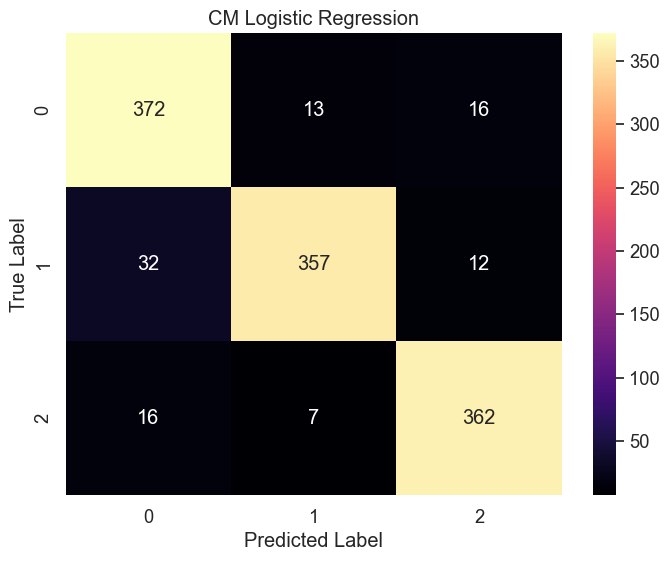

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, cmap='magma', fmt='g', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CM Logistic Regression')
plt.show()

In [ ]:
# Example new document
new_document = "I am feeling very happy and joyful today!"

# Preprocess and transform the new document into a feature vector
new_X = vectorizer.transform([new_document])

# Classify the new document
predicted_label = classifier.predict(new_X)
print("Predicted label:", predicted_label[0])


Predicted label: joy
